Epoch: 1 | Generator Loss: 0.731 | Discriminator Loss: 0.9908
Epoch: 2 | Generator Loss: 0.7864 | Discriminator Loss: 1.2052
Epoch: 3 | Generator Loss: 0.8006 | Discriminator Loss: 1.2048
Epoch: 4 | Generator Loss: 0.7692 | Discriminator Loss: 1.3142
Epoch: 5 | Generator Loss: 0.7276 | Discriminator Loss: 1.3599
Epoch: 6 | Generator Loss: 0.7185 | Discriminator Loss: 1.3887
Epoch: 7 | Generator Loss: 0.7275 | Discriminator Loss: 1.3625
Epoch: 8 | Generator Loss: 0.7287 | Discriminator Loss: 1.3532


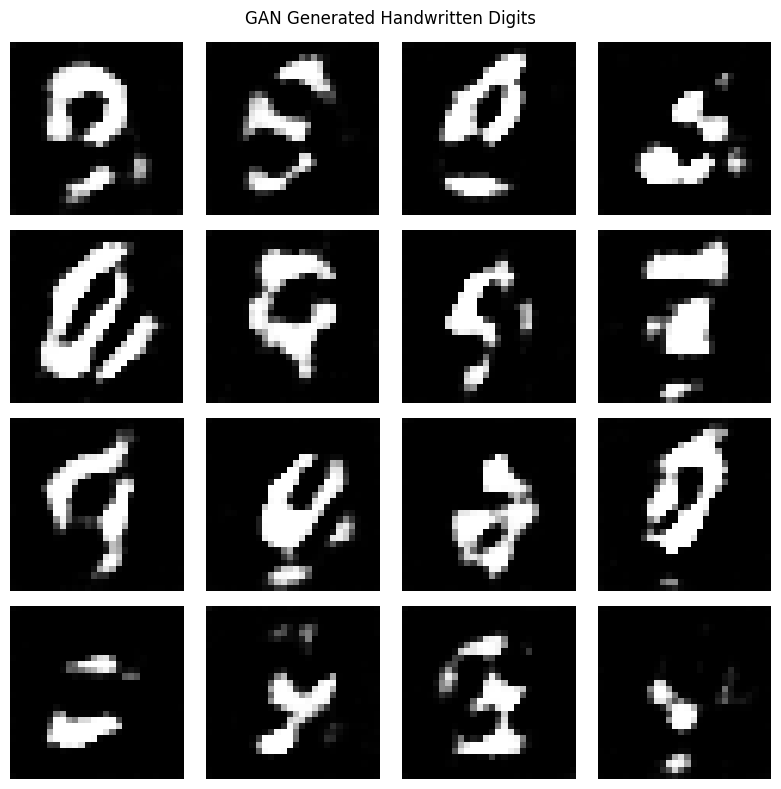

In [ ]:
# BY Vladlen Rebello | PRN: 23070521170

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers

# Load MNIST online
(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Use only 20,000 images to reduce training time and memory
X_train = X_train[:20000]

# Normalize images from 0-255 to -1 to 1
X_train = (X_train.astype("float32") - 127.5) / 127.5

# Add channel dimension
X_train = np.expand_dims(X_train, -1)

# Create batches
batch_size = 256

dataset = tf.data.Dataset.from_tensor_slices(X_train)
dataset = dataset.shuffle(20000).batch(batch_size)

# Generator
generator = tf.keras.Sequential([
    layers.Dense(7 * 7 * 64, input_shape=(100,)),
    layers.BatchNormalization(),
    layers.LeakyReLU(0.2),

    layers.Reshape((7, 7, 64)),

    layers.Conv2DTranspose(
        32, (4, 4),
        strides=2,
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.LeakyReLU(0.2),

    layers.Conv2DTranspose(
        16, (4, 4),
        strides=2,
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.LeakyReLU(0.2),

    layers.Conv2D(
        1, (3, 3),
        padding="same",
        activation="tanh"
    )
])

# Discriminator
discriminator = tf.keras.Sequential([
    layers.Conv2D(
        32, (4, 4),
        strides=2,
        padding="same",
        input_shape=(28, 28, 1)
    ),
    layers.LeakyReLU(0.2),
    layers.Dropout(0.3),

    layers.Conv2D(
        64, (4, 4),
        strides=2,
        padding="same"
    ),
    layers.LeakyReLU(0.2),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(1)
])

# Loss
loss_function = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

# Optimizers
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

# Training step
@tf.function
def train_step(real_images):

    noise = tf.random.normal(
        [tf.shape(real_images)[0], 100]
    )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        fake_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            real_images,
            training=True
        )

        fake_output = discriminator(
            fake_images,
            training=True
        )

        # Discriminator loss
        real_loss = loss_function(
            tf.ones_like(real_output),
            real_output
        )

        fake_loss = loss_function(
            tf.zeros_like(fake_output),
            fake_output
        )

        discriminator_loss = real_loss + fake_loss

        # Generator loss
        generator_loss = loss_function(
            tf.ones_like(fake_output),
            fake_output
        )

    # Gradients
    gen_gradients = gen_tape.gradient(
        generator_loss,
        generator.trainable_variables
    )

    disc_gradients = disc_tape.gradient(
        discriminator_loss,
        discriminator.trainable_variables
    )

    # Update weights
    generator_optimizer.apply_gradients(
        zip(gen_gradients, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(disc_gradients, discriminator.trainable_variables)
    )

    return generator_loss, discriminator_loss


# Train
epochs = 8

for epoch in range(epochs):

    g_losses = []
    d_losses = []

    for real_images in dataset:

        g_loss, d_loss = train_step(real_images)

        g_losses.append(float(g_loss))
        d_losses.append(float(d_loss))

    print(
        "Epoch:", epoch + 1,
        "| Generator Loss:", round(np.mean(g_losses), 4),
        "| Discriminator Loss:", round(np.mean(d_losses), 4)
    )

# Generate 16 new digits
noise = tf.random.normal((16, 100))

generated_images = generator(
    noise,
    training=False
)

# Convert -1 to 1 back to 0 to 1
generated_images = (generated_images + 1) / 2

# Display results
plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(
        generated_images[i, :, :, 0],
        cmap="gray"
    )
    plt.axis("off")

plt.suptitle("GAN Generated Handwritten Digits")
plt.tight_layout()
plt.show()